In [21]:
import kagglehub
from pycocotools.coco import COCO
import pandas as pd

path = kagglehub.dataset_download(
    "awsaf49/coco-2017-dataset",
    "coco2017/annotations/instances_train2017.json"
)

# Initialize COCO API
coco = COCO(path)

loading annotations into memory...
Done (t=9.23s)
creating index...
index created!


In [43]:
# Get category IDs to fetch subsets
category_ids = coco.getCatIds(catNms=['person', 'car', 'bicycle', 'truck', 'bus'])

# Get image Ids for these categories
image_ids = coco.getImgIds(catIds=category_ids)

# Get annotation Ids for these categories
ann_ids = coco.getAnnIds(imgIds=image_ids, catIds=category_ids)

# Get categories
categories = coco.loadCats(category_ids)

In [45]:
# Load data into dataframes
images_df = pd.DataFrame(coco.loadImgs(image_ids)).rename(columns={'id': 'image_id'})
ann_df = pd.DataFrame(coco.loadAnns(ann_ids))
category_df = pd.DataFrame(categories).rename(columns={'id': 'category_id'})

In [57]:
# Link annotations to category names
merged = pd.merge(ann_df, category_df[['category_id', 'name', 'supercategory']], on='category_id')
# Link annotations to image metadata
final = pd.merge(merged, images_df, on='image_id')

final.head()

,segmentation,area,iscrowd,image_id,bbox,category_id,id,name,supercategory,license,file_name,coco_url,height,width,date_captured,flickr_url
0,"[[23.92, 277.81, 33.74, 277.29, 36.84, 277.12,...",256.16895,0,451594,"[19.09, 262.47, 20.33, 15.34]",3,345093,car,vehicle,4,000000451594.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-16 18:21:46,http://farm9.staticflickr.com/8536/8643321887_...
1,"[[223.39, 294.77, 268.58, 296.51, 287.12, 304....",20363.41525,0,451594,"[187.47, 178.33, 188.87, 126.29]",6,365984,bus,vehicle,4,000000451594.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-16 18:21:46,http://farm9.staticflickr.com/8536/8643321887_...
2,"[[87.07, 276.46, 83.81, 278.64, 75.1, 278.64, ...",4680.21885,0,451594,"[44.63, 228.57, 95.78, 62.04]",8,398502,truck,vehicle,4,000000451594.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-16 18:21:46,http://farm9.staticflickr.com/8536/8643321887_...
3,"[[437.47, 268.88, 440.66, 256.32, 444.09, 252....",503.78305,0,451594,"[436.79, 246.27, 18.83, 47.47]",1,426346,person,person,4,000000451594.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-16 18:21:46,http://farm9.staticflickr.com/8536/8643321887_...
4,"[[464.8, 253.68, 464.28, 251.09, 463.63, 248.3...",413.69200,0,451594,"[460.13, 246.37, 12.97, 47.93]",1,452763,person,person,4,000000451594.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-16 18:21:46,http://farm9.staticflickr.com/8536/8643321887_...


In [24]:
print(images_df.head())
print(images_df.columns)
print(images_df.shape)

   license         file_name  \
0        4  000000451594.jpg   
1        1  000000268313.jpg   
2        3  000000066082.jpg   
3        4  000000283170.jpg   
4        3  000000542779.jpg   

                                            coco_url  height  width  \
0  http://images.cocodataset.org/train2017/000000...     480    640   
1  http://images.cocodataset.org/train2017/000000...     480    640   
2  http://images.cocodataset.org/train2017/000000...     427    640   
3  http://images.cocodataset.org/train2017/000000...     427    640   
4  http://images.cocodataset.org/train2017/000000...     463    640   

         date_captured                                         flickr_url  \
0  2013-11-16 18:21:46  http://farm9.staticflickr.com/8536/8643321887_...   
1  2013-11-14 23:52:45  http://farm4.staticflickr.com/3643/3366171911_...   
2  2013-11-16 21:20:43  http://farm4.staticflickr.com/3709/9245904373_...   
3  2013-11-16 22:21:42  http://farm8.staticflickr.com/7397/8724364789_..

In [25]:
print("Images rows length: ", len(images_df))
print("Images col length: ", len(images_df.columns))

Images rows length:  83
Images col length:  8


In [26]:
print(images_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   license        83 non-null     int64 
 1   file_name      83 non-null     object
 2   coco_url       83 non-null     object
 3   height         83 non-null     int64 
 4   width          83 non-null     int64 
 5   date_captured  83 non-null     object
 6   flickr_url     83 non-null     object
 7   id             83 non-null     int64 
dtypes: int64(4), object(4)
memory usage: 5.3+ KB
None


In [27]:
images_df.describe()

,license,height,width,id
count,83.000000,83.000000,83.00000,83.000000
mean,2.807229,474.891566,602.13253,322643.457831
std,1.580814,89.473121,72.62244,160917.365949
min,1.000000,301.000000,375.00000,1315.000000
25%,1.000000,427.000000,632.50000,220092.000000
50%,3.000000,463.000000,640.00000,334588.000000
75%,4.000000,480.500000,640.00000,452147.000000
max,7.000000,640.000000,640.00000,581061.000000


In [28]:
print(ann_df.head())
print(ann_df.columns)
print(ann_df.shape)

                                        segmentation         area  iscrowd  \
0  [[23.92, 277.81, 33.74, 277.29, 36.84, 277.12,...    256.16895        0   
1  [[223.39, 294.77, 268.58, 296.51, 287.12, 304....  20363.41525        0   
2  [[87.07, 276.46, 83.81, 278.64, 75.1, 278.64, ...   4680.21885        0   
3  [[437.47, 268.88, 440.66, 256.32, 444.09, 252....    503.78305        0   
4  [[464.8, 253.68, 464.28, 251.09, 463.63, 248.3...    413.69200        0   

   image_id                              bbox  category_id      id  
0    451594     [19.09, 262.47, 20.33, 15.34]            3  345093  
1    451594  [187.47, 178.33, 188.87, 126.29]            6  365984  
2    451594     [44.63, 228.57, 95.78, 62.04]            8  398502  
3    451594    [436.79, 246.27, 18.83, 47.47]            1  426346  
4    451594    [460.13, 246.37, 12.97, 47.93]            1  452763  
Index(['segmentation', 'area', 'iscrowd', 'image_id', 'bbox', 'category_id',
       'id'],
      dtype='object')
(154

In [29]:
print("Annotated rows files length: ", len(ann_df))
print("Annotated col length: ", len(ann_df.columns))

Annotated rows files length:  1546
Annotated col length:  7


In [30]:
print(ann_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546 entries, 0 to 1545
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   segmentation  1546 non-null   object 
 1   area          1546 non-null   float64
 2   iscrowd       1546 non-null   int64  
 3   image_id      1546 non-null   int64  
 4   bbox          1546 non-null   object 
 5   category_id   1546 non-null   int64  
 6   id            1546 non-null   int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 84.7+ KB
None


In [31]:
ann_df.describe()

,area,iscrowd,image_id,category_id,id
count,1546.000000,1546.000000,1546.000000,1546.000000,1.546000e+03
mean,4222.161447,0.015524,330874.106727,2.803364,1.397540e+10
std,12671.871271,0.123664,164307.645503,2.250383,1.113204e+11
min,6.973400,0.000000,1315.000000,1.000000,1.247960e+05
25%,229.966800,0.000000,230893.000000,1.000000,2.271218e+05
50%,656.970400,0.000000,335184.000000,2.000000,1.283557e+06
75%,2474.976950,0.000000,470618.000000,3.000000,1.751854e+06
max,196821.546850,1.000000,581061.000000,8.000000,9.003006e+11


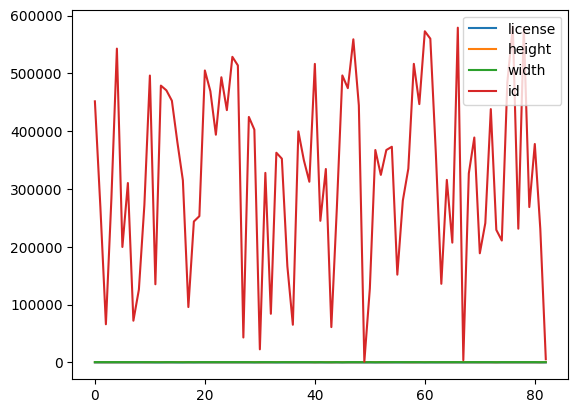

In [32]:
import matplotlib.pyplot as plt

images_df.plot()
plt.show()

In [33]:
category_df.head()

,supercategory,id,name
0,person,1,person
1,vehicle,2,bicycle
2,vehicle,3,car
3,vehicle,6,bus
4,vehicle,8,truck


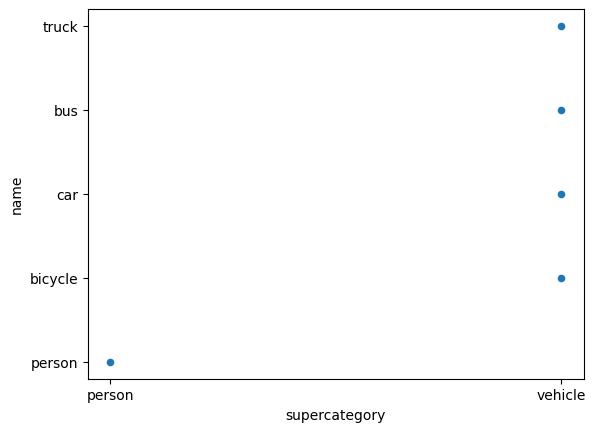

In [34]:
category_df.plot(kind='scatter', x='supercategory', y='name')
plt.show()

In [35]:
image_category_df = pd.merge([images_df, category_df])
ann_category_df = pd.concat([ann_df, category_df])

image_category_df.info()
ann_category_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88 entries, 0 to 4
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   license        83 non-null     float64
 1   file_name      83 non-null     object 
 2   coco_url       83 non-null     object 
 3   height         83 non-null     float64
 4   width          83 non-null     float64
 5   date_captured  83 non-null     object 
 6   flickr_url     83 non-null     object 
 7   id             88 non-null     int64  
 8   supercategory  5 non-null      object 
 9   name           5 non-null      object 
dtypes: float64(3), int64(1), object(6)
memory usage: 7.6+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 1551 entries, 0 to 4
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   segmentation   1546 non-null   object 
 1   area           1546 non-null   float64
 2   iscrowd        1546 non-null   flo

In [36]:
image_category_df.shape

(88, 10)

In [40]:
# Remove null rows
cleaned_image_df = image_category_df.dropna(how='all')
cleaned_image_df.shape

(88, 10)